# OpenCV Image Effects: Pencil Sketch and Cartoon
Notebook ini memproses gambar dari folder `image/` menjadi 2 efek visual:
1. Sketsa pensil
2. Efek kartun (dengan edge detection)

In [1]:
# Jika modul belum terpasang, jalankan baris berikut:
# %pip install opencv-python numpy matplotlib

In [2]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Ganti nama file jika ingin memakai gambar lain di folder image/
image_path = Path('image') / 'Screenshot from 2026-03-14 03-27-56.png'

if not image_path.exists():
    raise FileNotFoundError(f'File tidak ditemukan: {image_path}')

img_bgr = cv2.imread(str(image_path))
if img_bgr is None:
    raise ValueError('Gambar gagal dibaca oleh OpenCV')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print('Ukuran gambar:', img_rgb.shape)

Ukuran gambar: (255, 163, 3)


In [4]:
def pencil_sketch(img_bgr: np.ndarray) -> np.ndarray:
    """Membuat efek sketsa pensil klasik dengan teknik dodge blend."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    inverted = 255 - gray
    blurred = cv2.GaussianBlur(inverted, (21, 21), 0)
    sketch = cv2.divide(gray, 255 - blurred, scale=256.0)
    return sketch


def cartoon_effect(img_bgr: np.ndarray) -> np.ndarray:
    """Membuat efek kartun dengan edge detection + smoothing warna."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.medianBlur(gray, 7)

    # Edge map biner (garis kartun)
    edges = cv2.adaptiveThreshold(
        gray_blur,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        9,
        7,
    )

    # Smoothing warna agar tampak seperti blok warna kartun
    color = img_bgr.copy()
    for _ in range(2):
        color = cv2.bilateralFilter(color, d=9, sigmaColor=75, sigmaSpace=75)

    cartoon = cv2.bitwise_and(color, color, mask=edges)
    return cartoon

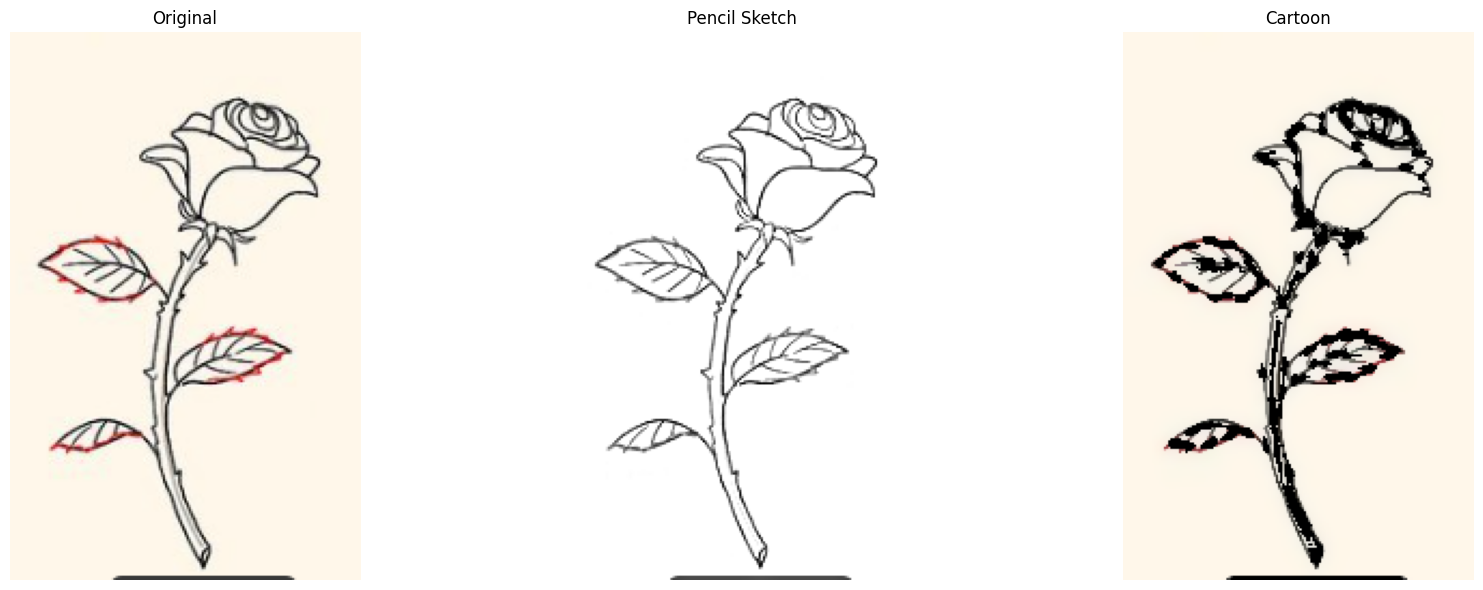

In [5]:
sketch = pencil_sketch(img_bgr)
cartoon_bgr = cartoon_effect(img_bgr)
cartoon_rgb = cv2.cvtColor(cartoon_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(sketch, cmap='gray')
axes[1].set_title('Pencil Sketch')
axes[1].axis('off')

axes[2].imshow(cartoon_rgb)
axes[2].set_title('Cartoon')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [6]:
output_dir = Path('image') / 'output'
output_dir.mkdir(parents=True, exist_ok=True)

sketch_path = output_dir / 'result_sketch.png'
cartoon_path = output_dir / 'result_cartoon.png'

cv2.imwrite(str(sketch_path), sketch)
cv2.imwrite(str(cartoon_path), cartoon_bgr)

print('Tersimpan:')
print('-', sketch_path)
print('-', cartoon_path)

Tersimpan:
- image/output/result_sketch.png
- image/output/result_cartoon.png
